# B-cell receptor repertoire analysis with `ov.airr`

When you are vaccinated, the immune response is *written into the B-cell
receptor (BCR) repertoire*. Each naive B cell carries a unique
immunoglobulin heavy chain (IgH), assembled by V(D)J recombination. On
encountering antigen, responding B cells enter germinal centres and undergo
**affinity maturation** — a Darwinian cycle of:

1. **Clonal expansion** — antigen-specific B cells proliferate, so their IgH
   sequences come to dominate the repertoire.
2. **Somatic hypermutation (SHM)** — the enzyme AID introduces point
   mutations into the rearranged V(D)J at a rate ~10^6-fold above background.
3. **Selection** — variants with higher antigen affinity are preferentially
   retained; the mutations that improve binding accumulate in the
   antigen-contacting **CDRs**, while the structural **framework regions
   (FWRs)** are kept intact by purifying selection.
4. **Class switching** — selected clones switch from IgM/IgD to IgG/IgA.

A BCR repertoire snapshot therefore carries a *molecular fossil record* of
this process. This tutorial reconstructs that record.

## The dataset

We use the **Laserson et al. 2014** influenza-vaccination IgH repertoire
(*PNAS* 2014, [PMID 24639495](https://pubmed.ncbi.nlm.nih.gov/24639495/)) --
high-throughput IgH sequencing from **one subject** at **two timepoints**:
**pre-vaccination (`-1h`)** and **day 7 post-vaccination (`+7d`)**, the peak
of the plasmablast response. The data are in standard **AIRR rearrangement
format**: one row per IgH sequence, with V/D/J gene calls, the CDR3 junction,
and IMGT-numbered alignments to the inferred germline.

## What `ov.airr` provides

`ov.airr` threads the **Immcantation** B-cell toolchain behind one registered
API -- clonal clustering (`pyscoper`), somatic hypermutation and BASELINe
selection (`pyshazam`), Ig genotyping (`pytigger`) and B-cell phylogenetics
(`pydowser`). Functions take a plain AIRR-format `pandas.DataFrame`, so the
whole analysis stays tabular and inspectable.

## 0. Setup

The B-cell side of `ov.airr` is table-native -- there is no AnnData here, just
an AIRR `DataFrame` that each step annotates with new columns.

In [1]:
import omicverse as ov
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
ov.plot_set()

/scratch/users/steorra/env/omicdev/lib/python3.10/site-packages/requests/__init__.py:86: RequestsDependencyWarning: Unable to find acceptable character detection dependency (chardet or charset_normalizer).
  warnings.warn(


/scratch/users/steorra/env/omicdev/lib/python3.10/site-packages/anndata/utils.py:434: FutureWarning: Importing read_loom from `anndata` is deprecated. Import anndata.io.read_loom instead.
  warnings.warn(msg, FutureWarning)


🔬 Starting plot initialization...
🧬 Detecting GPU devices…
🚫 No GPU devices found (CUDA/MPS/ROCm/XPU)

   ____            _     _    __                  
  / __ \____ ___  (_)___| |  / /__  _____________ 
 / / / / __ `__ \/ / ___/ | / / _ \/ ___/ ___/ _ \ 
/ /_/ / / / / / / / /__ | |/ /  __/ /  (__  )  __/ 
\____/_/ /_/ /_/_/\___/ |___/\___/_/  /____/\___/                                              

🔖 Version: 2.2.1rc1   📚 Tutorials: https://omicverse.readthedocs.io/
✅ plot_set complete.



## 1. Load the IgH repertoire

`ov.datasets.airr_bcr()` returns the Laserson 2014 IgH table as an
AIRR-format `DataFrame`. Each row is one rearranged heavy chain.

In [2]:
bcr = ov.datasets.airr_bcr()
print(f"sequences: {bcr.shape[0]}   columns: {bcr.shape[1]}")
print(f"timepoints: {bcr['sample_id'].value_counts().to_dict()}")
print(f"isotypes:   {bcr['c_call'].value_counts().to_dict()}")

🔍 Downloading data to ./data/bcr_repertoire.tsv.gz
⚠️ File ./data/bcr_repertoire.tsv.gz already exists
sequences: 1999   columns: 24
timepoints: {'-1h': 1000, '+7d': 999}
isotypes:   {'IGHM': 718, 'IGHG': 650, 'IGHA': 372, 'IGHD': 259}


The key AIRR columns the B-cell pipeline relies on:

| column | meaning |
|---|---|
| `sequence_alignment` | the observed IgH V(D)J, IMGT-gapped |
| `germline_alignment_d_mask` | the inferred **unmutated germline**, D-region masked with `N` |
| `v_call` / `j_call` / `c_call` | V gene, J gene, constant region (isotype) |
| `junction` | the CDR3 nucleotide sequence (the V-D-J join) |
| `sample_id` | timepoint -- `-1h` (pre) or `+7d` (day 7) |

Comparing `sequence_alignment` against `germline_alignment_d_mask`
position-by-position is exactly how somatic hypermutation is quantified. We
keep only **productive** rearrangements (functional, in-frame, no stop
codons) -- only these encode a real receptor.

In [3]:
db = bcr[bcr['productive'] == 'T'].copy()
print(f"productive sequences: {len(db)}  ({len(bcr) - len(db)} non-productive dropped)")
iso = db['c_call'].map({'IGHM': 'naive (IgM/IgD)', 'IGHD': 'naive (IgM/IgD)',
                        'IGHG': 'switched (IgG/IgA)', 'IGHA': 'switched (IgG/IgA)'})
print(iso.value_counts().to_dict())

productive sequences: 1780  (219 non-productive dropped)
{'naive (IgM/IgD)': 922, 'switched (IgG/IgA)': 858}


About 60% of the productive sequences are still **naive** (IgM/IgD) and
40% are **class-switched** (IgG/IgA) -- the switched fraction is the
antigen-experienced, affinity-matured compartment we expect to grow after
vaccination.

## 2. Clonal inference -- who shares a B-cell ancestor?

A **B-cell clone** is the set of sequences descended from a single
V(D)J-recombined naive cell. They share the same V and J genes and a
near-identical CDR3 (the junction), but differ by the point mutations SHM has
since introduced. Grouping sequences into clones is the foundation for
everything downstream -- SHM, selection and lineage trees are all
*per-clone* analyses.

### The distance-to-nearest threshold

How similar must two junctions be to call them clonally related? We let the
data answer. `ov.airr.distance_threshold` computes, for every sequence, the
distance to its **nearest neighbour** of the same V/J/junction-length, then
fits a threshold in the valley of that distribution.

In [4]:
threshold, db_dist = ov.airr.distance_threshold(db, model='ham', first=True)
dist = db_dist['dist_nearest'].dropna()
print(f"inferred clonal threshold: {threshold:.3f}")
print(f"sequences with a same-VJL neighbour: {len(dist)}")

inferred clonal threshold: 0.168
sequences with a same-VJL neighbour: 1744


The distance-to-nearest histogram is **bimodal**: a low-distance mode
(sequences that *are* clonally related -- same clone, separated only by SHM)
and a high-distance mode (sequences from unrelated rearrangements). A good
clonal threshold sits in the **valley** between them.

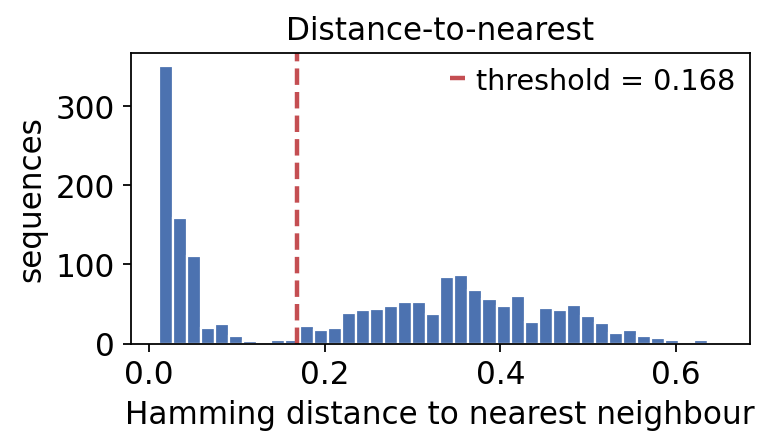

In [5]:
fig, ax = plt.subplots(figsize=(5, 3))
ax.hist(dist, bins=40, color='#4C72B0', edgecolor='white')
ax.axvline(threshold, color='#C44E52', ls='--', lw=2,
           label=f'threshold = {threshold:.3f}')
ax.set_xlabel('Hamming distance to nearest neighbour')
ax.set_ylabel('sequences'); ax.legend(); ax.set_title('Distance-to-nearest')
plt.tight_layout(); plt.show()

### Clonal clustering

We pass that threshold to `ov.airr.clonal_clustering`. The
`hierarchical` method groups sequences within each V/J/junction-length
partition by hierarchical clustering of junction distances; `complete`
linkage keeps clones tight (every member within-threshold of every other),
which avoids chaining a whole gene family into one giant pseudo-clone.

The source table already carries a `clone_id`; we drop it so the clustering
writes its own.

In [6]:
clones = ov.airr.clonal_clustering(
    db.drop(columns=['clone_id']),
    method='hierarchical', threshold=threshold, linkage='complete',
)
sizes = clones['clone_id'].value_counts()
print(f"B-cell clones inferred: {clones['clone_id'].nunique()}")
print(f"  singletons:          {(sizes == 1).sum()}")
print(f"  expanded (>=3 seqs): {(sizes >= 3).sum()}")
print(f"  largest clone:       {sizes.iloc[0]} sequences")

B-cell clones inferred: 1018
  singletons:          894
  expanded (>=3 seqs): 49
  largest clone:       165 sequences


Most clones are **singletons** -- sampled once, never expanded. A small
set of **expanded clones** carries many sequences each: these are the
proliferating, antigen-responding lineages. Plotting the clone-size rank
curve makes the skew obvious.

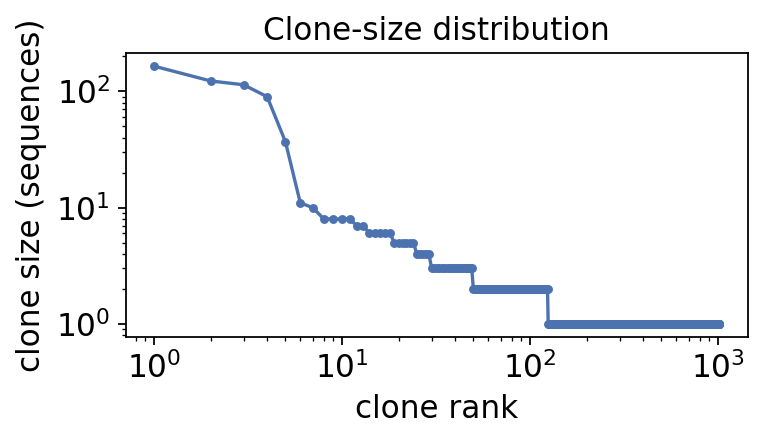

In [7]:
rank = np.arange(1, len(sizes) + 1)
fig, ax = plt.subplots(figsize=(5, 3))
ax.loglog(rank, sizes.values, marker='o', ms=3, color='#4C72B0')
ax.set_xlabel('clone rank'); ax.set_ylabel('clone size (sequences)')
ax.set_title('Clone-size distribution')
plt.tight_layout(); plt.show()

### Are the expanded clones the vaccine response?

If expansion is vaccine-driven, the largest clones should be enriched at
**day 7**, not pre-vaccination. We cross-tabulate the biggest clones by
timepoint.

In [8]:
big = sizes[sizes >= 8].index
tp = (clones[clones['clone_id'].isin(big)]
      .groupby(['clone_id', 'sample_id']).size()
      .unstack(fill_value=0).sort_values('+7d', ascending=False))
print(tp.head(8))
day7_frac = tp['+7d'].sum() / tp.sum().sum()
print(f"\nday-7 share of the largest clones: {day7_frac:.0%}")

sample_id  +7d  -1h
clone_id           
1010       165    0
1016       123    0
1013       114    0
1011        90    0
1014        37    0
1012        11    0
940         10    0
1015         8    0

day-7 share of the largest clones: 98%


The largest clones are overwhelmingly **day-7** sequences -- clonal
expansion is the first fingerprint of the vaccine response.

## 3. Somatic hypermutation

Affinity maturation runs on mutation. `ov.airr.mutation_analysis` compares
each sequence's `sequence_alignment` to its `germline_alignment_d_mask` and
counts the substitutions. Mutations are classified as:

- **Replacement (R)** -- change the encoded amino acid (can alter affinity).
- **Silent (S)** -- synonymous (visible to AID, invisible to selection).

With `combine=True` we get a single whole-V-region **mutation frequency**
(mutations per base) per sequence -- the standard scalar measure of how
hypermutated a B cell is.

In [9]:
mut = ov.airr.mutation_analysis(clones, frequency=True, combine=True)
mut = mut.rename(columns={'mu_freq': 'shm_freq'})
print(f"mean SHM frequency: {mut['shm_freq'].mean():.3f}  "
      f"({mut['shm_freq'].mean() * 100:.1f}% of V-region bases mutated)")
print(f"range: {mut['shm_freq'].min():.3f} - {mut['shm_freq'].max():.3f}")

mean SHM frequency: 0.041  (4.1% of V-region bases mutated)
range: 0.000 - 0.218


A mean of ~4% mutated bases is typical for a mixed memory/naive IgH
repertoire. The real question is whether SHM **rose with vaccination** -- so
we split it by timepoint and by isotype.

In [10]:
by_time = mut.groupby('sample_id')['shm_freq'].mean()
by_iso = mut.groupby('c_call')['shm_freq'].mean()
print("mean SHM by timepoint:")
print((by_time * 100).round(1).astype(str) + ' %')
print("\nmean SHM by isotype:")
print((by_iso * 100).round(1).astype(str) + ' %')

mean SHM by timepoint:
sample_id
+7d    6.6 %
-1h    1.9 %
Name: shm_freq, dtype: object

mean SHM by isotype:
c_call
IGHA    7.7 %
IGHD    0.5 %
IGHG    7.8 %
IGHM    0.9 %
Name: shm_freq, dtype: object


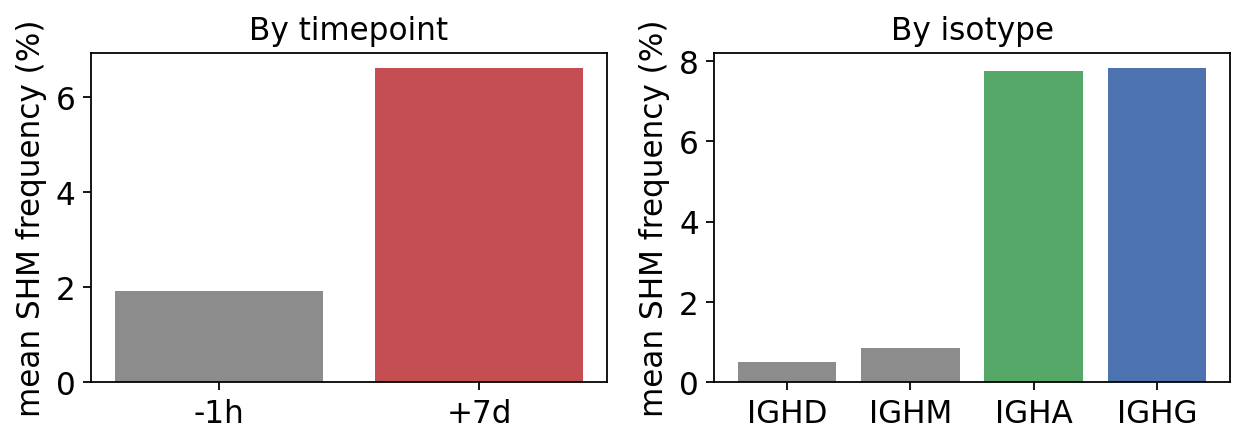

In [11]:
order_t, order_i = ['-1h', '+7d'], ['IGHD', 'IGHM', 'IGHA', 'IGHG']
fig, ax = plt.subplots(1, 2, figsize=(8, 3))
ax[0].bar(order_t, [by_time[t] * 100 for t in order_t], color=['#8C8C8C', '#C44E52'])
ax[1].bar(order_i, [by_iso[i] * 100 for i in order_i],
          color=['#8C8C8C', '#8C8C8C', '#55A868', '#4C72B0'])
ax[0].set_title('By timepoint'); ax[1].set_title('By isotype')
for a in ax: a.set_ylabel('mean SHM frequency (%)')
plt.tight_layout(); plt.show()

Two textbook signatures. **SHM roughly triples from pre-vaccination to
day 7** -- the day-7 repertoire is dominated by hypermutated, germinal-centre
graduates. And SHM tracks isotype almost perfectly: **naive IgM/IgD are
near-germline**, while **class-switched IgG/IgA carry heavy SHM loads** --
exactly as expected, since class switching and SHM are co-induced in the
germinal centre.

### The SHM targeting model

AID does not mutate uniformly -- its activity depends on the local DNA
sequence context (the classic **WRC/GYW hotspot** motifs).
`ov.airr.shm_targeting` learns a **targeting model** directly from the
observed sequences: a per-5-mer mutability profile plus a substitution
matrix, fitted from every mutation in the dataset.

In [12]:
tmodel = ov.airr.shm_targeting(clones, minNumMutations=20,
                               minNumSeqMutations=200)
mutability = pd.Series(tmodel.mutability, index=tmodel.mut_names).dropna()
top = mutability.sort_values(ascending=False).head(8)
print("most mutable 5-mer motifs (centre base is the mutated position):")
print(top.round(3))

most mutable 5-mer motifs (centre base is the mutated position):
TTGTA    0.012
AGACA    0.010
GCGCG    0.009
AAGCG    0.009
AAATC    0.008
GAATA    0.008
AAATG    0.008
AAATT    0.008
dtype: float64


The 5-mers ranked here are the most mutable contexts *this subject's*
data supports -- with a few hundred mutations the estimates are noisy, so the
canonical `WRC`/`GYW` enrichment is only partly resolved (a deep repertoire
sharpens it). The point is the model itself: it is what makes the BASELINe
selection test in the next section rigorous, by providing the *null
expectation* of where mutations would land **in the absence of
selection**.

## 4. Antigen-driven selection -- the BASELINe framework

SHM scatters mutations; **selection** decides which survive. The
**BASELINe** framework (Yaari et al. 2012) tests this. The logic:

- Silent (S) mutations are invisible to selection -- they fix the *neutral
  mutation rate*.
- Given that rate and the SHM targeting model, BASELINe predicts the
  **expected number of replacement (R) mutations** per region under
  neutrality.
- The deviation of *observed* from *expected* R mutations is the **selection
  strength Sigma** (`baseline_sigma`):
  - **Sigma > 0** -- more R mutations than expected -> **positive selection**
    (affinity-improving changes are retained; expected in **CDRs**).
  - **Sigma < 0** -- fewer R mutations than expected -> **negative / purifying
    selection** (R changes are removed; expected in **FWRs**, which must stay
    structurally intact).

`ov.airr.baseline_selection` builds per-clone consensus sequences, runs the
BASELINe calculation per IMGT region, and summarises Sigma with a confidence
interval and p-value. We run it on the **expanded clones** (>=3 sequences) --
the lineages that have actually undergone enough SHM to test.

In [13]:
expanded = clones[clones['clone_id'].isin(sizes[sizes >= 3].index)].copy()
print(f"expanded-clone sequences: {len(expanded)}  "
      f"in {expanded['clone_id'].nunique()} clones")
selection = ov.airr.baseline_selection(expanded, region='v').drop_duplicates()
print(selection.round(3).to_string(index=False))

expanded-clone sequences: 736  in 49 clones


region  baseline_sigma  baseline_ci_lower  baseline_ci_upper  baseline_ci_pvalue
  cdr1          -0.014             -0.554              0.572              -0.466
  cdr2           0.041             -0.397              0.512               0.441
  fwr1          -1.011             -1.596             -0.442              -0.000
  fwr2          -0.763             -1.315             -0.201              -0.005
  fwr3          -0.667             -0.926             -0.413              -0.000


Reading the table by region:

- **FWR1, FWR2, FWR3** -- strongly **negative Sigma** (about -0.7 to -1.0),
  all with **p < 0.01**. The framework regions are under significant
  **purifying selection**: replacement mutations there break the
  immunoglobulin fold, so they are purged.
- **CDR1, CDR2** -- Sigma about 0, **not significant**. The antigen-contacting
  loops are *released from that constraint* -- replacement mutations there are
  tolerated rather than purged.

The biologically meaningful quantity is the **CDR-minus-FWR contrast**: CDRs
are free to accept affinity-altering mutations precisely where FWRs are not.
That differential is the molecular signature of antigen-driven selection.

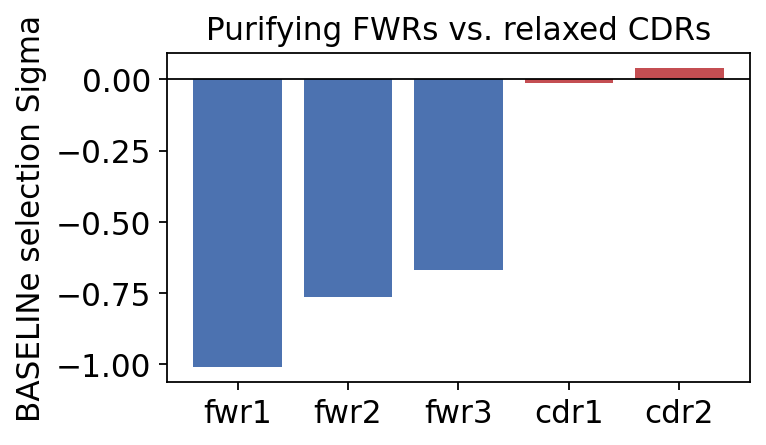

In [14]:
piv = selection.set_index('region')['baseline_sigma']
reg = ['fwr1', 'fwr2', 'fwr3', 'cdr1', 'cdr2']
colors = ['#4C72B0' if r.startswith('fwr') else '#C44E52' for r in reg]
fig, ax = plt.subplots(figsize=(5, 3))
ax.bar(reg, [piv[r] for r in reg], color=colors)
ax.axhline(0, color='k', lw=0.8)
ax.set_ylabel('BASELINe selection Sigma')
ax.set_title('Purifying FWRs vs. relaxed CDRs')
plt.tight_layout(); plt.show()

### Does selection differ between naive and switched cells?

If selection is antigen-driven, it should be sharper in the
**class-switched** (germinal-centre-experienced) compartment. We group the
BASELINe scores by isotype class.

In [15]:
expanded['isotype_class'] = expanded['c_call'].map(
    {'IGHM': 'naive', 'IGHD': 'naive', 'IGHG': 'switched', 'IGHA': 'switched'})
sel_grp = ov.airr.baseline_selection(
    expanded, group_by='isotype_class', region='v').drop_duplicates()
print(sel_grp.round(3).to_string(index=False))

isotype_class region  baseline_sigma  baseline_ci_lower  baseline_ci_upper  baseline_ci_pvalue
     switched   cdr1          -0.012             -0.565              0.589              -0.469
     switched   cdr2           0.025             -0.415              0.497               0.470
     switched   fwr1          -1.022             -1.624             -0.437              -0.001
     switched   fwr2          -0.820             -1.379             -0.251              -0.003
     switched   fwr3          -0.664             -0.927             -0.406              -0.000
        naive   cdr1          -0.085             -1.539              1.566              -0.437
        naive   cdr2           0.623             -2.189              5.254               0.423
        naive   fwr1          -0.651             -2.199              0.886              -0.196
        naive   fwr2           1.301             -1.310              5.590               0.229
        naive   fwr3          -0.771             -

The **class-switched** clones show the clean, significant
FWR-purifying pattern; the naive clones -- near-germline, barely mutated --
have wide confidence intervals and no significant selection, because there
simply has not been enough SHM for selection to act on. Selection is a
property of the *antigen-experienced* repertoire.

## 5. B-cell lineage trees

A **lineage tree** is the phylogeny *inside* a single clone. Its root is the
inferred unmutated common ancestor (the naive germline V(D)J); each branch is
an SHM step; each tip is an observed cell. The tree shows the *order* in
which mutations were acquired and how the clone diversified -- the
affinity-maturation trajectory itself.

`ov.airr.lineage_trees` formats each clone and builds a maximum-parsimony
tree (`pydowser`). Tree-building needs **one consensus germline per clone**,
so we first collapse each clone's germline to its position-wise majority
sequence. We build trees for several moderately expanded clones (parsimony on
the very largest clones is slow and adds no extra concepts).

In [16]:
from collections import Counter

def consensus(seqs):
    arr = np.array([list(s) for s in seqs])
    return ''.join(Counter(col).most_common(1)[0][0] for col in arr.T)

pick = sizes[(sizes >= 8) & (sizes <= 37)].index[:5]
tree_in = clones[clones['clone_id'].isin(pick)].copy()
for col in ['germline_alignment', 'germline_alignment_d_mask']:
    tree_in[col] = tree_in.groupby('clone_id')[col].transform(consensus)
print(f"building lineage trees for {tree_in['clone_id'].nunique()} clones")

building lineage trees for 5 clones


In [17]:
trees = ov.airr.lineage_trees(tree_in, build='pratchet')
summary = pd.DataFrame({
    'clone_id': trees['clone_id'],
    'n_tips': [t.n_tip for t in trees['trees']],
    'tree_length': [round(sum(t.edge_length), 3) for t in trees['trees']],
})
print(summary.to_string(index=False))

clone_id  n_tips  tree_length
    1014      19        0.182
     940      10        0.168
     107       7        0.102
    1015       6        0.078
    1012       5        0.081


Each row is one clone's tree: `n_tips` distinct sequences connected by a
total branch length (`tree_length`) measured in substitutions. A larger tree
length means a clone that has accumulated more SHM diversity -- it has been
maturing longer or harder. We draw the trees with `pydowser`.

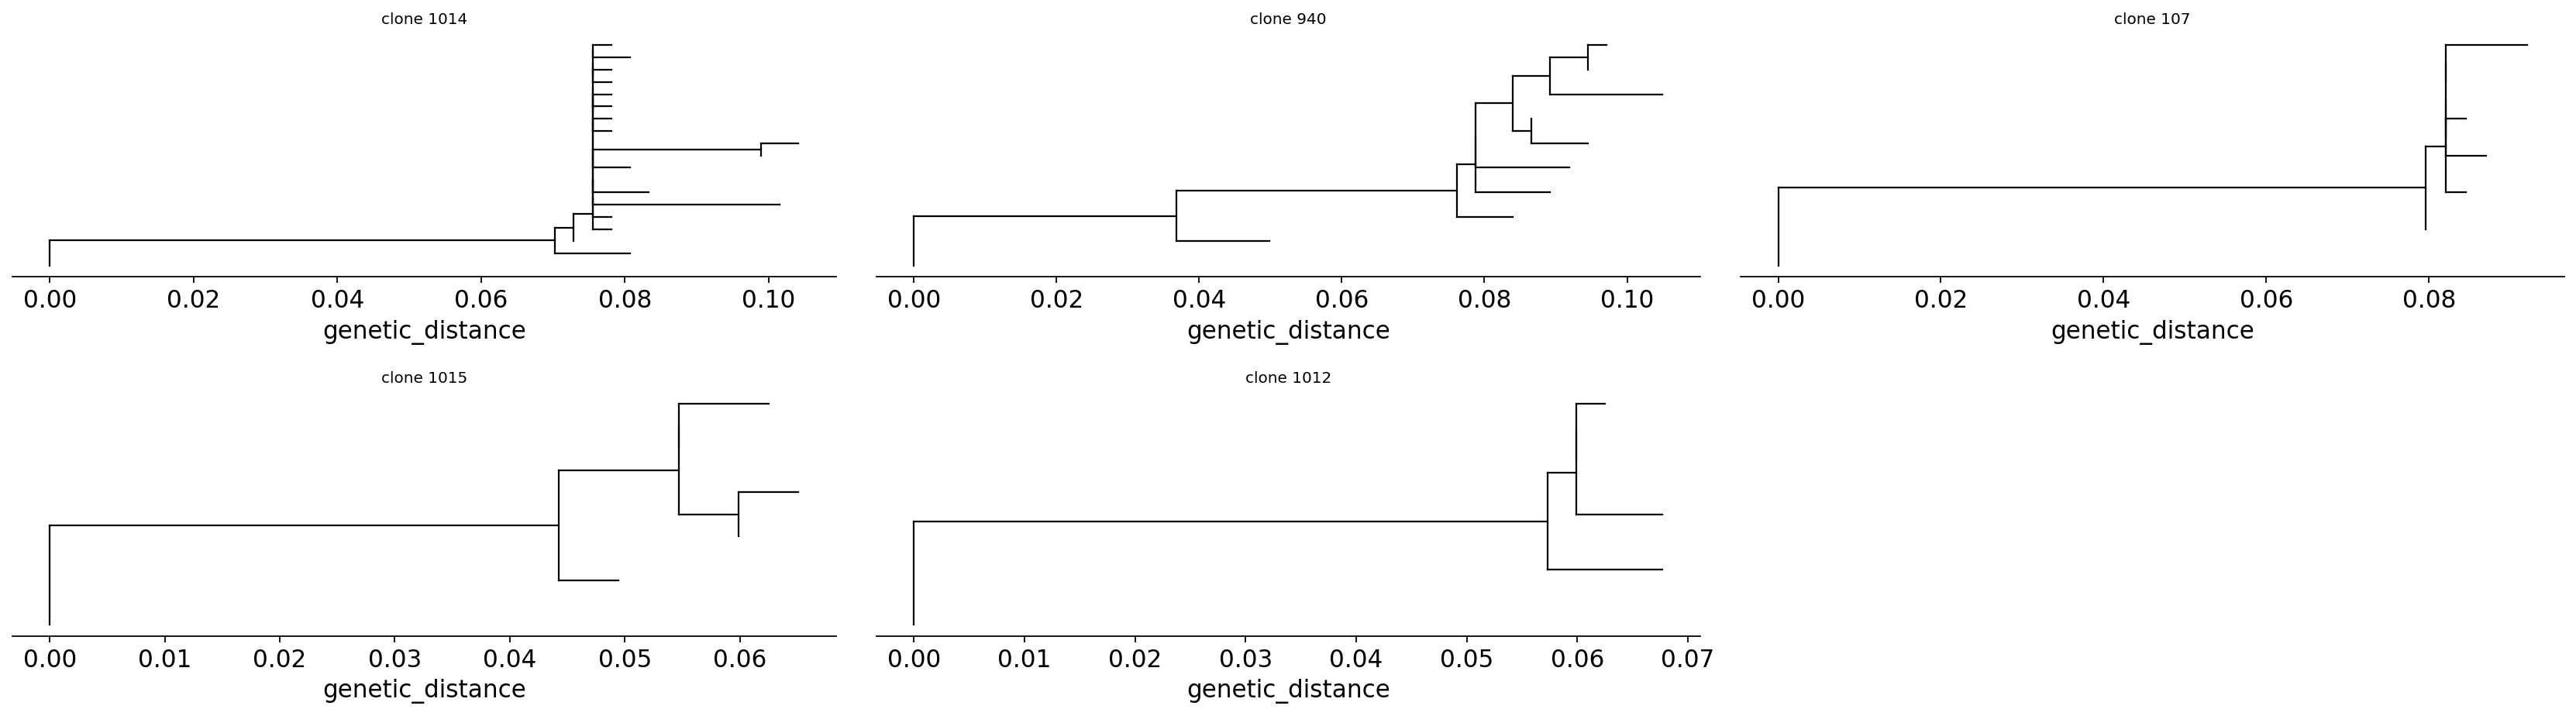

In [18]:
import pydowser
axes = pydowser.plotTrees(trees, scale=True, tip_labels=False, ncol=3)
for ax, cid in zip(axes, trees['clone_id']):
    ax.set_title(f'clone {cid}', fontsize=9)
plt.tight_layout(); plt.show()

Each tree fans out from the germline root. The **branching topology** is
the affinity-maturation history made visible: long internal branches are
bursts of SHM, and clusters of closely related tips are sub-lineages of
related affinity variants -- the population that selection was choosing
between. A clone that is a deep, well-resolved tree (rather than a star of
identical sequences) is one that genuinely diversified inside a germinal
centre.

## 6. V-gene genotype

Every SHM and selection call is made *relative to the germline*. But germline
IGHV alleles are **polymorphic** between individuals -- using the wrong allele
as reference would mis-score the first few "mutations". `pytigger` infers the
subject's personal IGHV genotype straight from the data.

`ov.airr.infer_genotype` keeps, for each V gene, only the alleles a person
actually carries -- judged from the alleles seen on **unmutated** sequences
(where the call is unambiguous). The Immcantation-style gene calls in this
dataset carry a `Homsap ... F` prefix, so we strip them to bare allele names
first.

In [19]:
import pytigger
geno_in = clones.copy()
for col in ['v_call', 'j_call']:
    geno_in[col] = (geno_in[col].str.replace('Homsap ', '', regex=False)
                    .str.replace(r' (F|ORF|P)$', '', regex=True)
                    .str.split(',').str[0])
germline_ighv = pytigger.load_sample_germline_ighv()
print(f"IMGT germline IGHV reference: {len(germline_ighv)} alleles")

IMGT germline IGHV reference: 344 alleles


In [20]:
genotype = ov.airr.infer_genotype(geno_in, germline_db=germline_ighv,
                                  method='frequency')
print(f"IGHV genes in this subject's genotype: {len(genotype)}")
het = genotype[genotype['alleles'].str.contains(',')]
print(f"heterozygous genes (>1 allele): {len(het)}")
print(genotype[['gene', 'alleles', 'counts']].head(8).to_string(index=False))

IGHV genes in this subject's genotype: 40
heterozygous genes (>1 allele): 9
    gene  alleles counts
 IGHV1-2    02,04    2,1
 IGHV1-3       01      9
 IGHV1-8       01      9
IGHV1-18       01      7
IGHV1-24       01      9
IGHV1-46       01      4
IGHV1-58       02      5
IGHV1-69 02,01,06  8,8,7


The genotype lists the IGHV genes this individual uses and which
allele(s) of each -- most genes appear with a single allele, a few are
**heterozygous**. Pinning the genotype this way is what makes the SHM and
selection scores above germline-accurate rather than confounded by allelic
polymorphism.

### Novel alleles

`ov.airr.find_novel_alleles` goes one step further: it looks for IGHV alleles
**not in the IMGT reference at all**, by testing whether apparent "mutations"
at specific positions accumulate in a way that betrays an unrecorded germline
polymorphism rather than SHM.

In [21]:
novel = ov.airr.find_novel_alleles(geno_in, germline_ighv)
n_novel = int(novel['polymorphism_call'].notna().sum())
print(f"candidate novel IGHV alleles: {n_novel}")
print(f"genes screened: {len(novel)}")

candidate novel IGHV alleles: 0
genes screened: 1


No novel alleles pass here -- expected for a single subject at this
sequencing depth (novel-allele discovery needs many unmutated sequences per
gene). The screen ran cleanly, confirming the IMGT reference is adequate for
this subject.

## 7. Synthesis -- the affinity-maturation picture

Every step has added one panel to the same story. Putting them side by side:

In [22]:
fwr_sig, cdr_sig = piv[['fwr1','fwr2','fwr3']].mean(), piv[['cdr1','cdr2']].mean()
report = {
    'B-cell clones / expanded': f"{clones['clone_id'].nunique()} / {(sizes >= 3).sum()}",
    'day-7 share of top clones': f"{day7_frac:.0%}",
    'mean SHM  -1h -> +7d': f"{by_time['-1h']*100:.1f}% -> {by_time['+7d']*100:.1f}%",
    'BASELINe Sigma  FWR / CDR': f"{fwr_sig:+.2f} / {cdr_sig:+.2f}",
}
for k, v in report.items():
    print(f"  {k:<28s}: {v}")

  B-cell clones / expanded    : 1018 / 49
  day-7 share of top clones   : 98%
  mean SHM  -1h -> +7d        : 1.9% -> 6.6%
  BASELINe Sigma  FWR / CDR   : -0.81 / +0.01


**The molecular fossil record of a vaccine response.** From a single
subject's IgH repertoire, `ov.airr` reconstructed the three coupled engines
of affinity maturation:

1. **Clonal expansion** -- hierarchical clonal clustering resolved the
   repertoire into B-cell clones; the largest are dominated by **day-7**
   sequences. Antigen drove specific lineages to proliferate.

2. **Somatic hypermutation** -- comparing each sequence to its germline showed
   SHM **rising roughly 3-fold from pre-vaccination to day 7** (1.9% to 6.6%),
   and tracking isotype: near-germline naive IgM/IgD vs. heavily mutated
   class-switched IgG/IgA. A 5-mer **targeting model** was fitted to supply
   the neutral mutation expectation.

3. **Antigen-driven selection** -- the **BASELINe** test showed significant
   **purifying selection in the framework regions** (Sigma < 0, p < 0.01) and
   **relaxed CDRs** (Sigma about 0). The framework is held intact while the
   antigen-contacting loops are free to mutate -- the CDR-vs-FWR contrast that
   defines selection. The signal is carried by the class-switched compartment.

4. **Lineage history** -- maximum-parsimony **lineage trees** turned each
   expanded clone into a phylogeny rooted at its naive ancestor, making the
   order of SHM events and the diversification of affinity variants
   explicit.

5. **Germline calibration** -- `pytigger` inferred the subject's personal
   IGHV genotype, so every mutation above was scored against the correct
   germline.

Clonal expansion + somatic hypermutation + framework-purifying / CDR-relaxed
selection -- read directly off the BCR repertoire -- *is* the signature of
vaccine-induced affinity maturation.